# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore and understand the dataset before model training. This analysis helps identify data distributions, relationships between features and the target variable, potential outliers, and patterns that may influence model performance.

---

## EDA Roadmap

1. Target Variable Analysis
2. Univariate Analysis
3. Bivariate Analysis
4. Correlation Analysis
5. Outlier Analysis
6. Key Insights

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Better plot appearance
plt.style.use("ggplot")

In [3]:
df = pd.read_csv("../Dataset/Processed/MindSense_AI_Cleaned_Dataset_v1.csv")

In [4]:
df.head()

,Gender,Age,Working Professional or Student,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,...,Degree_M.Tech,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_PhD
0,0,37,1,-1.0,2.0,-1.0,-1.0,4.0,2,1,...,0,1,0,0,0,0,0,0,0,0
1,1,60,1,-1.0,4.0,-1.0,-1.0,3.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,42,1,-1.0,2.0,-1.0,-1.0,3.0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,44,1,-1.0,3.0,-1.0,-1.0,5.0,2,2,...,0,0,0,0,0,1,0,0,0,0
4,1,48,1,-1.0,4.0,-1.0,-1.0,3.0,2,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df["Depression"].value_counts()

Depression
No     2101
Yes     455
Name: count, dtype: int64

In [6]:
df["Depression"].value_counts(normalize=True) * 100

Depression
No     82.198748
Yes    17.801252
Name: proportion, dtype: float64

## Target Variable Analysis

The target variable is **Depression**, which is a binary classification variable.

### Class Distribution

| Class | Count | Percentage |
|-------|------:|-----------:|
| No | 2101 | 82.20% |
| Yes | 455 | 17.80% |

### Observation

- The dataset is moderately imbalanced.
- Most individuals belong to the **No Depression** class.
- Model evaluation should not rely on accuracy alone.
- Additional metrics such as Precision, Recall, F1-Score, and ROC-AUC will be considered during model evaluation.

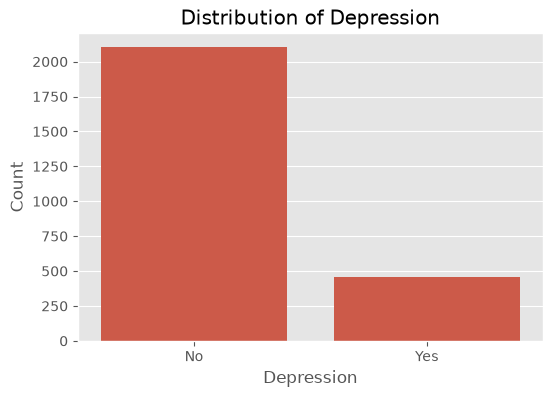

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Depression"
)

plt.title("Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Count")

plt.show()

### Interpretation

- The count plot shows that the dataset is **moderately imbalanced**.
- Most records belong to the **No Depression** class.
- The minority class (**Depression = Yes**) contains significantly fewer samples.
- During model evaluation, accuracy alone may be misleading.
- Therefore, additional evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC will be used to assess model performance.

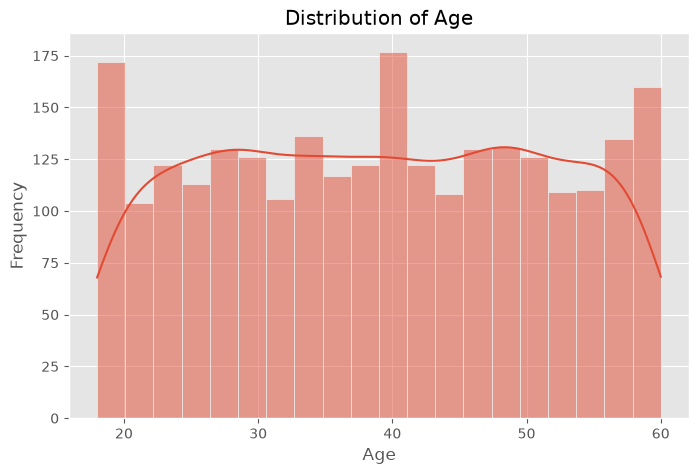

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

- The Age variable ranges approximately from 18 to 60 years.
- The age distribution appears fairly uniform across the dataset.
- No dominant age group is observed.
- The distribution does not show strong skewness.
- No obvious outliers are visible in the histogram; a box plot will be used later for confirmation.
- The dataset includes participants from a broad range of ages, which may improve the generalizability of the machine learning model.

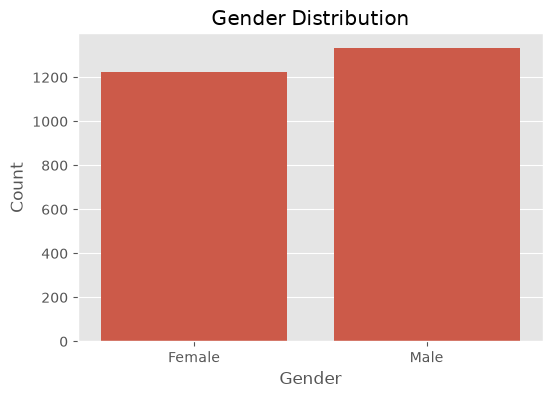

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Gender"].map({0: "Female", 1: "Male"})
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains both male and female participants.
- Male participants are slightly more numerous than female participants.
- The gender distribution is relatively balanced, with no significant dominance of either category.
- A balanced gender distribution helps reduce gender-related bias during machine learning model training.

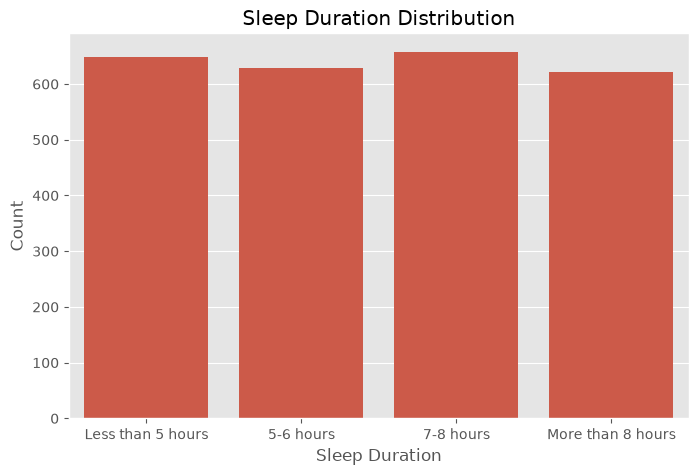

In [13]:
sleep_order = [
    "Less than 5 hours",
    "5-6 hours",
    "7-8 hours",
    "More than 8 hours"
]

sleep_labels = {
    0: "Less than 5 hours",
    1: "5-6 hours",
    2: "7-8 hours",
    3: "More than 8 hours"
}

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Sleep Duration"].map(sleep_labels),
    order=sleep_order
)

plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Duration")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains participants across all four sleep duration categories.
- The distribution of sleep duration is fairly balanced, with no category showing an overwhelming dominance.
- Participants sleeping 7–8 hours and less than 5 hours appear slightly more frequent than the other categories.
- Participants sleeping 5–6 hours and more than 8 hours have slightly lower frequencies.
- Overall, the dataset captures a diverse range of sleeping habits, which is beneficial for analyzing the relationship between sleep duration and mental health.

### 4.4 Dietary Habits

Objective:
To analyze the distribution of dietary habits among participants and understand the prevalence of different eating patterns in the dataset.

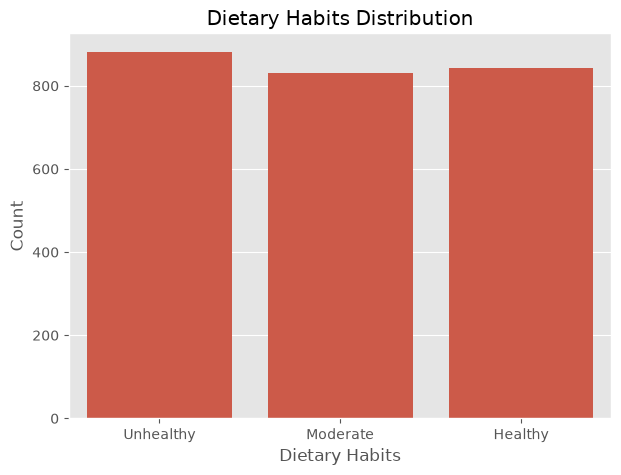

In [14]:
dietary_labels = {
    0: "Unhealthy",
    1: "Moderate",
    2: "Healthy"
}

dietary_order = [
    "Unhealthy",
    "Moderate",
    "Healthy"
]

plt.figure(figsize=(7,5))

sns.countplot(
    x=df["Dietary Habits"].map(dietary_labels),
    order=dietary_order
)

plt.title("Dietary Habits Distribution")
plt.xlabel("Dietary Habits")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains participants from all three dietary habit categories: Unhealthy, Moderate, and Healthy.
- The Unhealthy dietary habit category has the highest number of participants.
- The Healthy and Moderate categories have slightly fewer participants and appear to have similar frequencies.
- Overall, the distribution is fairly balanced, although the Unhealthy category is the most common.
- The presence of all dietary habit categories provides useful diversity for analyzing the relationship between eating habits and mental health.

### 4.5 Financial Stress

Objective:
To analyze the distribution of financial stress levels among participants and understand the prevalence of different stress levels in the dataset.

In [15]:
sorted(df["Financial Stress"].unique())

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

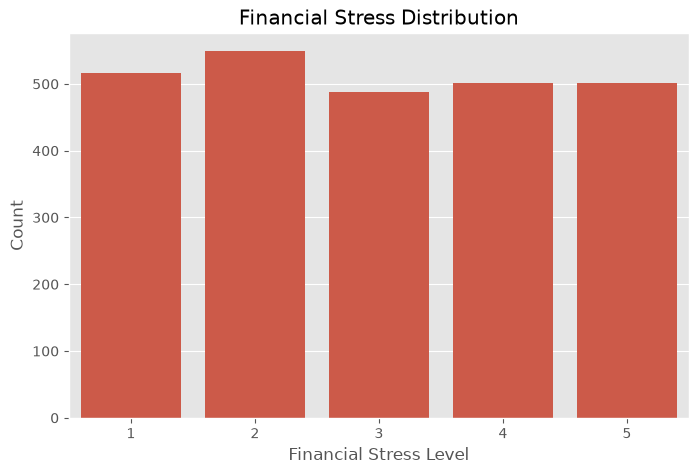

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Financial Stress",
    order=[1, 2, 3, 4, 5]
)

plt.title("Financial Stress Distribution")
plt.xlabel("Financial Stress Level")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains participants across all five financial stress levels.
- The distribution is relatively balanced, with no single stress level dominating the dataset.
- Financial Stress Level 2 has the highest number of participants.
- Financial Stress Level 3 has the lowest number of participants.
- The differences between the categories are relatively small, indicating a well-distributed dataset.
- A balanced distribution of financial stress levels is beneficial for analyzing its relationship with depression in later stages of the project.

### 4.6 Working Professional or Student

Objective:
To analyze the distribution of participants based on their occupational status (Working Professional or Student).

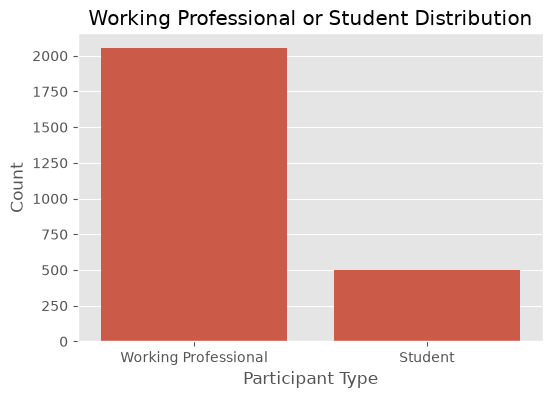

In [17]:
status_labels = {
    0: "Student",
    1: "Working Professional"
}

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Working Professional or Student"].map(status_labels)
)

plt.title("Working Professional or Student Distribution")
plt.xlabel("Participant Type")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset includes both working professionals and students.
- Working professionals constitute the majority of the participants.
- Students represent a smaller portion of the dataset.
- The participant distribution is imbalanced, with working professionals being the dominant group.
- This imbalance should be considered during later analyses, as work-related factors may have greater representation than student-related factors.

### 4.7 Academic Pressure

Objective:
To analyze the distribution of academic pressure levels among participants.

In [18]:
sorted(df["Academic Pressure"].unique())

[np.float64(-1.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0)]

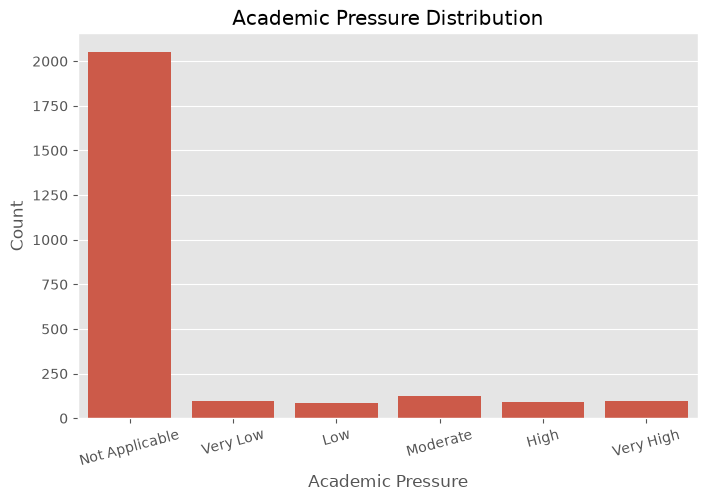

In [19]:
academic_labels = {
    -1: "Not Applicable",
     1: "Very Low",
     2: "Low",
     3: "Moderate",
     4: "High",
     5: "Very High"
}

academic_order = [
    "Not Applicable",
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Academic Pressure"].map(academic_labels),
    order=academic_order
)

plt.title("Academic Pressure Distribution")
plt.xlabel("Academic Pressure")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

### Observation

- The "Not Applicable" category has the highest number of participants.
- This is expected because the majority of participants are working professionals, for whom academic pressure is not applicable.
- Among students, the Moderate academic pressure level appears to be the most common.
- The remaining academic pressure levels (Very Low, Low, High, and Very High) have relatively similar frequencies.
- This distribution indicates that academic pressure analysis should primarily focus on the student population rather than the entire dataset.

## 4.8 Work Pressure Distribution

Objective:
To analyze the distribution of work pressure levels among participants and understand the prevalence of different work pressure levels in the dataset.

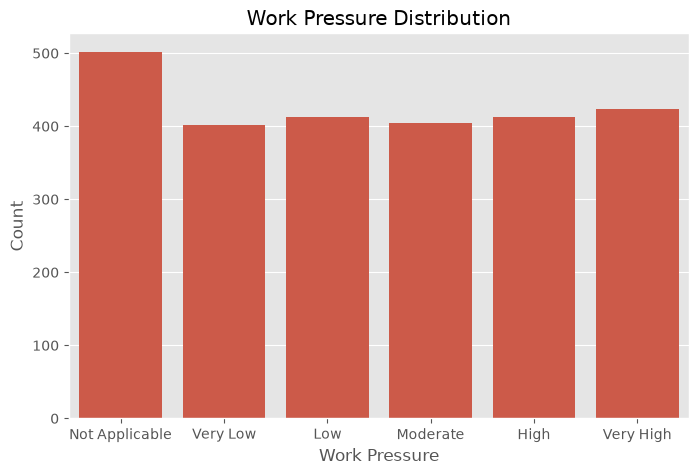

In [20]:
work_labels = {
    -1: "Not Applicable",
     1: "Very Low",
     2: "Low",
     3: "Moderate",
     4: "High",
     5: "Very High"
}

work_order = [
    "Not Applicable",
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Work Pressure"].map(work_labels),
    order=work_order
)

plt.title("Work Pressure Distribution")
plt.xlabel("Work Pressure")
plt.ylabel("Count")

plt.show()

## Observation
- The dataset contains participants across different work pressure levels.
- The Not Applicable category represents students, for whom work pressure does not apply.
- Among working professionals, the distribution of work pressure levels ranges from Very Low to Very High.
- The graph provides a good distribution for analyzing work pressure in later stages of the project.

## 4.10 Study Satisfaction Distribution

Objective:
To analyze the distribution of study satisfaction levels among participants and understand the prevalence of different satisfaction levels.

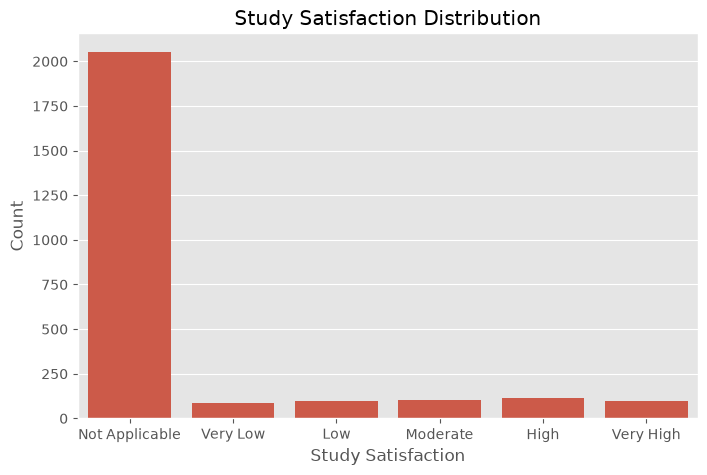

In [21]:
study_labels = {
    -1: "Not Applicable",
     1: "Very Low",
     2: "Low",
     3: "Moderate",
     4: "High",
     5: "Very High"
}

study_order = [
    "Not Applicable",
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Study Satisfaction"].map(study_labels),
    order=study_order
)

plt.title("Study Satisfaction Distribution")
plt.xlabel("Study Satisfaction")
plt.ylabel("Count")

plt.show()

### Observation
- The dataset contains participants with different study satisfaction levels.
- The Not Applicable category corresponds to working professionals.
- Among students, study satisfaction ranges from Very Low to Very High.
- This feature can later be analyzed to understand its relationship with depression.

## 4.11 Job Satisfaction Distribution

Objective:
To analyze the distribution of job satisfaction levels among participants and understand the prevalence of different job satisfaction levels.

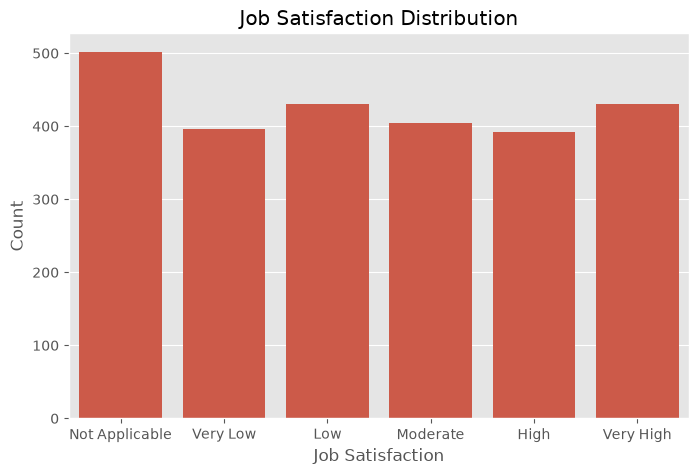

In [22]:
job_labels = {
    -1: "Not Applicable",
     1: "Very Low",
     2: "Low",
     3: "Moderate",
     4: "High",
     5: "Very High"
}

job_order = [
    "Not Applicable",
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Job Satisfaction"].map(job_labels),
    order=job_order
)

plt.title("Job Satisfaction Distribution")
plt.xlabel("Job Satisfaction")
plt.ylabel("Count")

plt.show()

### Observation
- The dataset contains participants with different job satisfaction levels.
- The Not Applicable category represents students.
- Among working professionals, job satisfaction ranges from Very Low to Very High.
- The distribution provides sufficient variation for further analysis with the target variable.

## 4.12 Family History of Mental Illness

Objective:
To analyze the distribution of participants based on their family history of mental illness.

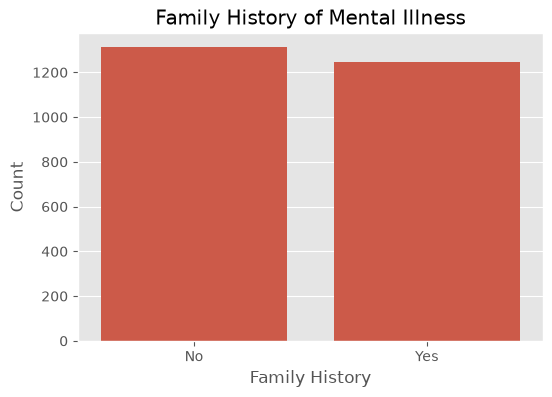

In [23]:
family_labels = {
    0: "No",
    1: "Yes"
}

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Family History of Mental Illness"].map(family_labels),
    order=["No", "Yes"]
)

plt.title("Family History of Mental Illness")
plt.xlabel("Family History")
plt.ylabel("Count")

plt.show()

### Observation
- The dataset includes participants both with and without a family history of mental illness.
- The graph shows the overall distribution of this feature.
- This variable will be useful for analyzing whether family history is associated with depression.

## 4.13 Suicidal Thoughts Distribution

Objective:
To analyze the distribution of participants based on whether they have experienced suicidal thoughts.

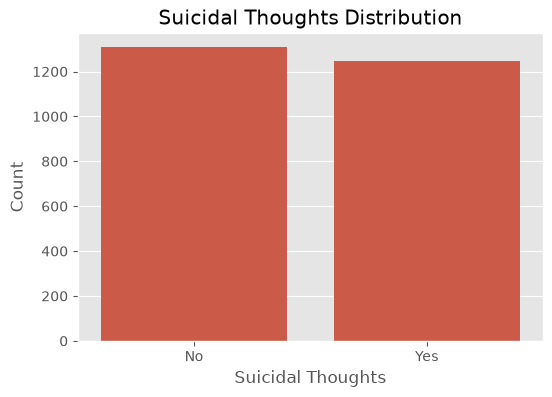

In [24]:
suicidal_labels = {
    0: "No",
    1: "Yes"
}

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Have you ever had suicidal thoughts ?"].map(suicidal_labels),
    order=["No", "Yes"]
)

plt.title("Suicidal Thoughts Distribution")
plt.xlabel("Suicidal Thoughts")
plt.ylabel("Count")

plt.show()

### Observation
- The dataset includes participants who have and have not experienced suicidal thoughts.
- The graph shows the overall distribution of suicidal thoughts among participants.
- This feature is expected to play an important role in predicting depression and will be explored further during bivariate analysis and model training.

# 5. Bivariate Analysis

Bivariate Analysis examines the relationship between two variables. In this study, each feature is analyzed against the target variable (**Depression**) to identify patterns, associations, and potential factors related to depression. The insights obtained from this analysis will support feature selection and model development.

---

## 5.1 Age vs Depression

### Objective

To compare the age distribution of participants with and without depression and identify any noticeable differences between the two groups.

### Code

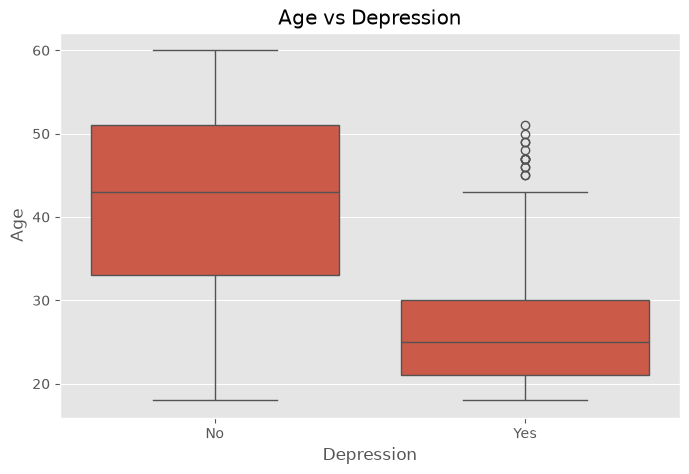

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Depression",
    y="Age",
    data=df
)

plt.title("Age vs Depression")
plt.xlabel("Depression")
plt.ylabel("Age")

plt.show()

### Observation

- Participants with **depression (Yes)** generally belong to a younger age group compared to those without depression.
- The median age of participants with depression is noticeably lower than that of participants without depression.
- The age distribution of participants without depression is more spread out, indicating greater variability in age.
- A few potential outliers are observed in the depression group, representing older participants with depression.
- Based on the visualization, age appears to have a relationship with depression. However, additional statistical analysis is required to determine whether this relationship is statistically significant.

## 5.2 Gender vs Depression

### Objective

To compare the distribution of depression among male and female participants and identify whether depression varies across gender.

### Code

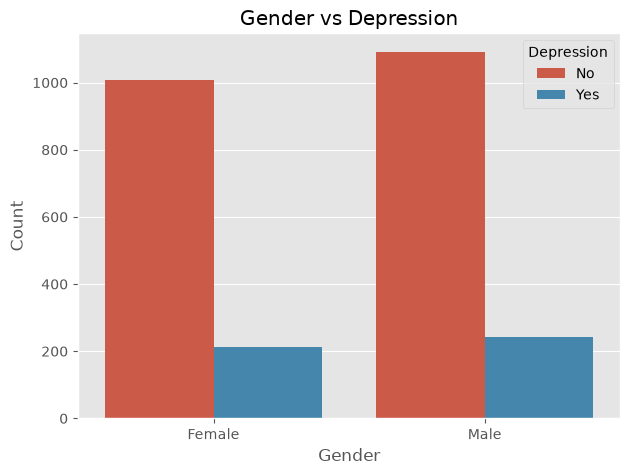

In [26]:
gender_labels = {
    0: "Female",
    1: "Male"
}

plt.figure(figsize=(7,5))

sns.countplot(
    x=df["Gender"].map(gender_labels),
    hue=df["Depression"]
)

plt.title("Gender vs Depression")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- The dataset contains a relatively balanced distribution of male and female participants, with males slightly outnumbering females.
- For both genders, the number of participants without depression is considerably higher than those with depression, which is consistent with the overall class distribution of the dataset.
- The number of male participants with depression is slightly higher than that of female participants. However, this may be influenced by the larger number of male participants in the dataset.
- Based on the visualization alone, there is no clear evidence that gender has a strong association with depression.
- Further statistical analysis or percentage-based comparison is required to determine whether the observed differences are statistically significant.

## 5.3 Sleep Duration vs Depression

### Objective

To compare the distribution of depression across different sleep duration categories and examine whether sleep duration shows any relationship with depression.

### Code

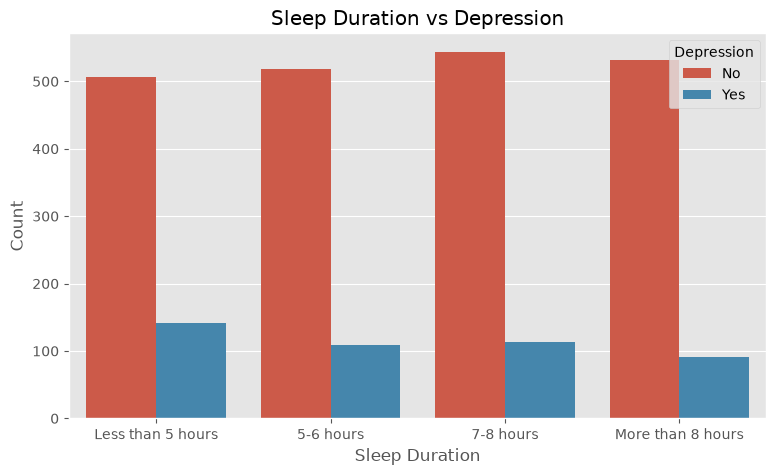

In [27]:
sleep_labels = {
    0: "Less than 5 hours",
    1: "5-6 hours",
    2: "7-8 hours",
    3: "More than 8 hours"
}

sleep_order = [
    "Less than 5 hours",
    "5-6 hours",
    "7-8 hours",
    "More than 8 hours"
]

plt.figure(figsize=(9,5))

sns.countplot(
    x=df["Sleep Duration"].map(sleep_labels),
    hue=df["Depression"],
    order=sleep_order
)

plt.title("Sleep Duration vs Depression")
plt.xlabel("Sleep Duration")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- The number of participants without depression is higher than those with depression across all sleep duration categories, which is consistent with the overall class distribution of the dataset.
- Participants sleeping **less than 5 hours** show the highest number of depression cases compared to the other sleep duration groups.
- The number of participants with depression generally decreases as sleep duration increases, with the **More than 8 hours** category showing the fewest depression cases.
- Participants sleeping **7–8 hours** have the highest number of individuals without depression, suggesting that this sleep duration is the most common among non-depressed participants in the dataset.
- Based on the visualization, sleep duration appears to be associated with depression. However, further statistical analysis is required to determine whether this relationship is statistically significant.

## 5.4 Dietary Habits vs Depression

### Objective

To compare the distribution of depression across different dietary habit categories and examine whether dietary habits show any relationship with depression.

### Code

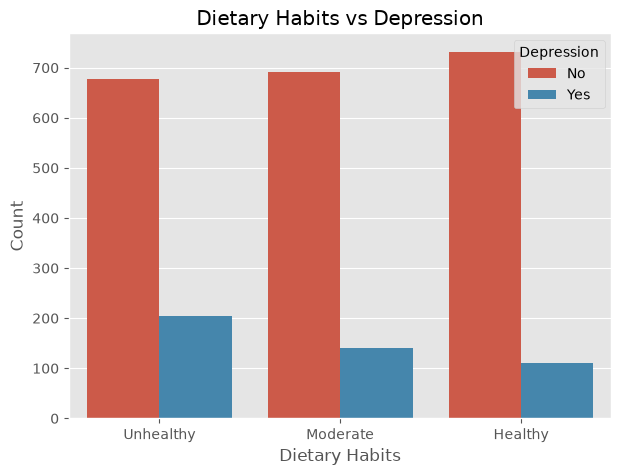

In [28]:
diet_labels = {
    0: "Unhealthy",
    1: "Moderate",
    2: "Healthy"
}

diet_order = [
    "Unhealthy",
    "Moderate",
    "Healthy"
]

plt.figure(figsize=(7,5))

sns.countplot(
    x=df["Dietary Habits"].map(diet_labels),
    hue=df["Depression"],
    order=diet_order
)

plt.title("Dietary Habits vs Depression")
plt.xlabel("Dietary Habits")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- The number of participants without depression is higher than those with depression across all dietary habit categories, which is consistent with the overall class distribution of the dataset.
- Participants with **unhealthy dietary habits** have the highest number of depression cases among the three categories.
- The number of depression cases decreases from **Unhealthy** to **Moderate** and is lowest among participants with **Healthy** dietary habits.
- Participants with **healthy dietary habits** have the highest number of individuals without depression and the lowest number of depression cases.
- Based on the visualization, dietary habits appear to be associated with depression. However, further statistical analysis is required to determine whether this relationship is statistically significant.

## 5.5 Financial Stress vs Depression

### Objective

To compare the distribution of depression across different financial stress levels and examine whether financial stress shows any relationship with depression.

### Code

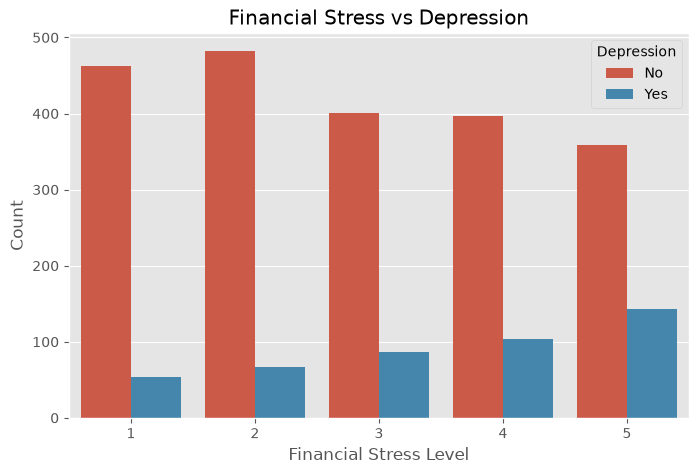

In [29]:
financial_order = [1, 2, 3, 4, 5]

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Financial Stress"],
    hue=df["Depression"],
    order=financial_order
)

plt.title("Financial Stress vs Depression")
plt.xlabel("Financial Stress Level")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- The number of participants without depression is higher than those with depression across all financial stress levels, which is consistent with the overall class distribution of the dataset.
- The number of participants with depression increases progressively as the financial stress level increases.
- Participants with **Financial Stress Level 5** exhibit the highest number of depression cases, while **Financial Stress Level 1** has the lowest.
- Conversely, the number of participants without depression gradually decreases as financial stress levels increase.
- Based on the visualization, higher financial stress appears to be associated with a greater occurrence of depression. However, further statistical analysis is required to confirm whether this relationship is statistically significant.

## 5.6 Working Professional or Student vs Depression

### Objective

To compare the distribution of depression between working professionals and students and examine whether occupation status shows any relationship with depression.

### Code

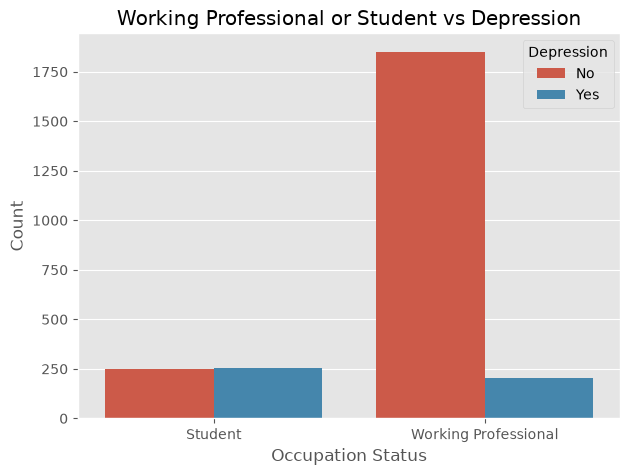

In [30]:
status_labels = {
    0: "Student",
    1: "Working Professional"
}

plt.figure(figsize=(7,5))

sns.countplot(
    x=df["Working Professional or Student"].map(status_labels),
    hue=df["Depression"],
    order=["Student", "Working Professional"]
)

plt.title("Working Professional or Student vs Depression")
plt.xlabel("Occupation Status")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- The dataset contains a significantly higher number of **working professionals** than **students**.
- Among students, the number of participants with and without depression is relatively similar, indicating a comparatively higher occurrence of depression within this group.
- Among working professionals, the majority of participants do not have depression, while the number of participants with depression is considerably lower.
- The observed difference in depression counts may be influenced by the unequal number of participants in each occupation category.
- Based on the visualization, occupation status appears to be associated with depression. However, percentage-based analysis or statistical testing is required to determine whether this relationship is statistically significant.

In [31]:
# Students only
students_df = df[df["Working Professional or Student"] == 0]

## 5.7 Academic Pressure vs Depression

### Objective

To compare the distribution of depression across different academic pressure levels among students and examine whether academic pressure shows any relationship with depression.

### Code

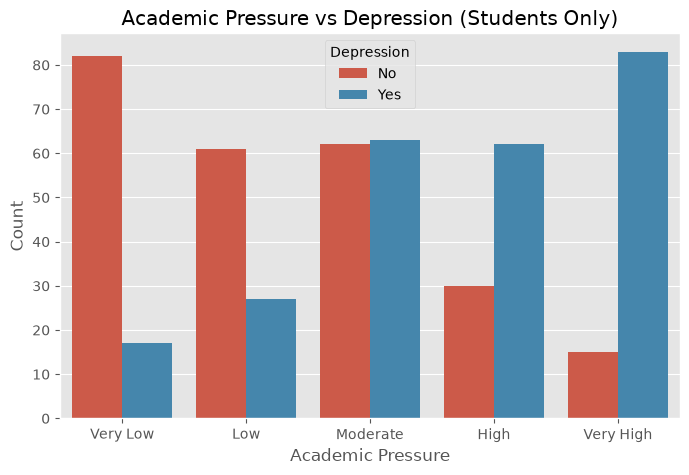

In [32]:
academic_labels = {
    1: "Very Low",
    2: "Low",
    3: "Moderate",
    4: "High",
    5: "Very High"
}

academic_order = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

plt.figure(figsize=(8,5))

sns.countplot(
    x=students_df["Academic Pressure"].map(academic_labels),
    hue=students_df["Depression"],
    order=academic_order
)

plt.title("Academic Pressure vs Depression (Students Only)")
plt.xlabel("Academic Pressure")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- Among students, the number of participants without depression is highest at **Very Low Academic Pressure** and gradually decreases as academic pressure increases.
- Conversely, the number of participants with depression increases as academic pressure levels rise.
- At **Moderate Academic Pressure**, the number of participants with and without depression is nearly equal.
- At **High** and **Very High Academic Pressure**, participants with depression outnumber those without depression.
- Based on the visualization, higher academic pressure appears to be associated with a greater occurrence of depression among students. However, further statistical analysis is required to determine whether this relationship is statistically significant.

## 5.8 Work Pressure vs Depression (Working Professionals Only)

### Objective

To compare the distribution of depression across different work pressure levels among working professionals and examine whether work pressure shows any relationship with depression.

### Code

In [33]:
# Working professionals only
professionals_df = df[df["Working Professional or Student"] == 1]

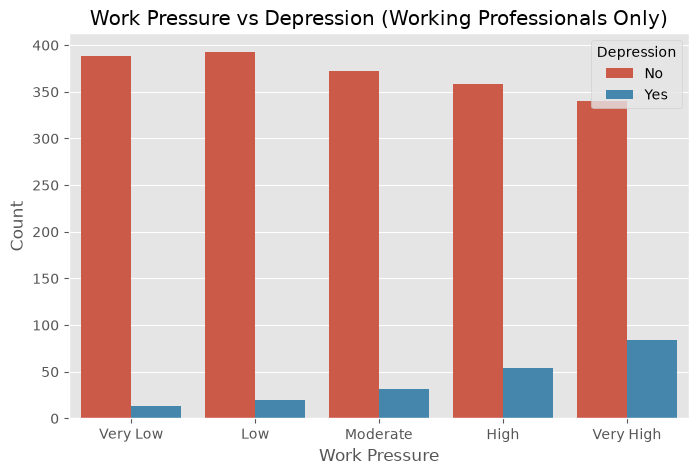

In [34]:
work_labels = {
    1: "Very Low",
    2: "Low",
    3: "Moderate",
    4: "High",
    5: "Very High"
}

work_order = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

plt.figure(figsize=(8,5))

sns.countplot(
    x=professionals_df["Work Pressure"].map(work_labels),
    hue=professionals_df["Depression"],
    order=work_order
)

plt.title("Work Pressure vs Depression (Working Professionals Only)")
plt.xlabel("Work Pressure")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- Among working professionals, the number of participants without depression is higher than those with depression across all work pressure levels.
- The number of participants with depression gradually increases as work pressure levels increase.
- Participants experiencing **Very High Work Pressure** have the highest number of depression cases, while those with **Very Low Work Pressure** have the lowest.
- The number of participants without depression shows a gradual decline as work pressure increases.
- Based on the visualization, higher work pressure appears to be associated with a greater occurrence of depression among working professionals. However, further statistical analysis is required to determine whether this relationship is statistically significant.

## 5.9 Study Satisfaction vs Depression (Students Only)

### Objective

To compare the distribution of depression across different study satisfaction levels among students and examine whether study satisfaction shows any relationship with depression.

### Code

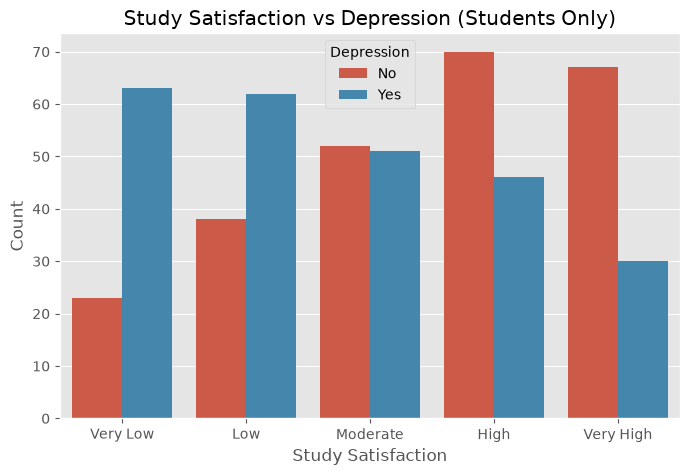

In [35]:
study_labels = {
    1: "Very Low",
    2: "Low",
    3: "Moderate",
    4: "High",
    5: "Very High"
}

study_order = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

plt.figure(figsize=(8,5))

sns.countplot(
    x=students_df["Study Satisfaction"].map(study_labels),
    hue=students_df["Depression"],
    order=study_order
)

plt.title("Study Satisfaction vs Depression (Students Only)")
plt.xlabel("Study Satisfaction")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- Among students, the number of participants with depression is highest at **Very Low Study Satisfaction** and gradually decreases as study satisfaction increases.
- Conversely, the number of participants without depression increases as study satisfaction levels increase.
- At **Moderate Study Satisfaction**, the number of participants with and without depression is nearly equal.
- Participants with **High** and **Very High Study Satisfaction** are more likely to be in the non-depression group than in the depression group.
- Based on the visualization, higher study satisfaction appears to be associated with a lower occurrence of depression among students. However, further statistical analysis is required to determine whether this relationship is statistically significant.

## 5.10 Job Satisfaction vs Depression (Working Professionals Only)

### Objective

To compare the distribution of depression across different job satisfaction levels among working professionals and examine whether job satisfaction shows any relationship with depression.

### Code

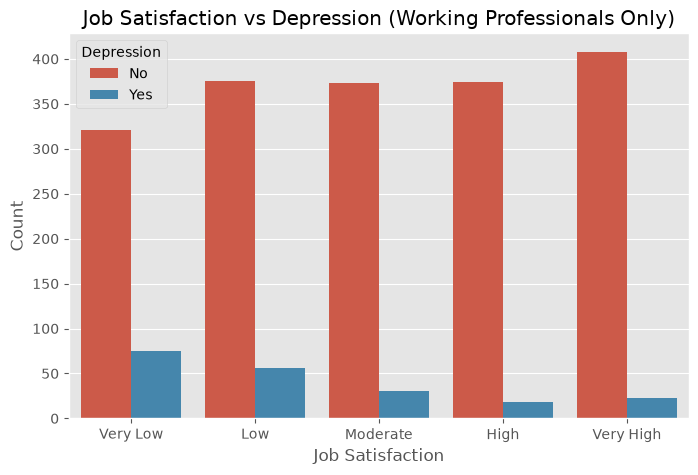

In [36]:
job_labels = {
    1: "Very Low",
    2: "Low",
    3: "Moderate",
    4: "High",
    5: "Very High"
}

job_order = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

plt.figure(figsize=(8,5))

sns.countplot(
    x=professionals_df["Job Satisfaction"].map(job_labels),
    hue=professionals_df["Depression"],
    order=job_order
)

plt.title("Job Satisfaction vs Depression (Working Professionals Only)")
plt.xlabel("Job Satisfaction")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- Among working professionals, the number of participants without depression is higher than those with depression across all job satisfaction levels.
- Participants with **Very Low Job Satisfaction** have the highest number of depression cases.
- The number of participants with depression generally decreases as job satisfaction levels increase.
- Participants with **Very High Job Satisfaction** have the highest number of individuals without depression and one of the lowest numbers of depression cases.
- Based on the visualization, higher job satisfaction appears to be associated with a lower occurrence of depression among working professionals. However, further statistical analysis is required to determine whether this relationship is statistically significant.

## 5.11 Family History of Mental Illness vs Depression

### Objective

To compare the distribution of depression among participants with and without a family history of mental illness and examine whether family history shows any relationship with depression.

### Code

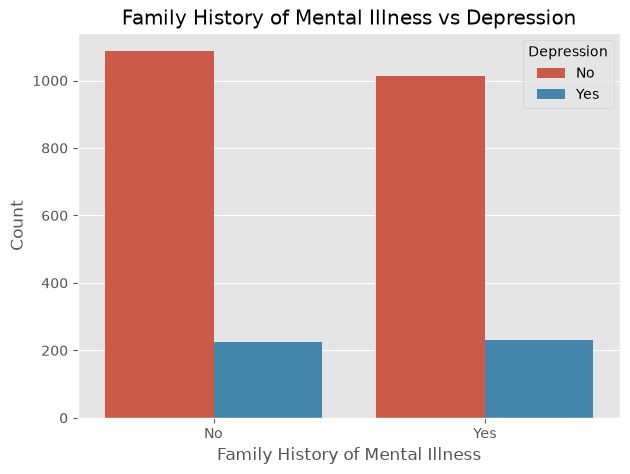

In [37]:
family_labels = {
    0: "No",
    1: "Yes"
}

plt.figure(figsize=(7,5))

sns.countplot(
    x=df["Family History of Mental Illness"].map(family_labels),
    hue=df["Depression"],
    order=["No", "Yes"]
)

plt.title("Family History of Mental Illness vs Depression")
plt.xlabel("Family History of Mental Illness")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- The number of participants without depression is higher than those with depression for both categories of family history.
- Participants with a **family history of mental illness** show a slightly higher number of depression cases compared to those without a family history.
- The number of participants without depression is relatively similar in both categories, indicating a balanced distribution of this feature.
- The visual difference between the two groups is relatively small compared to other features such as academic pressure or financial stress.
- Based on the visualization, family history of mental illness may be associated with depression. However, further statistical analysis is required to determine whether this relationship is statistically significant.

## 5.12 Suicidal Thoughts vs Depression

### Objective

To compare the distribution of depression among participants with and without suicidal thoughts and examine whether suicidal thoughts show any relationship with depression.

### Code

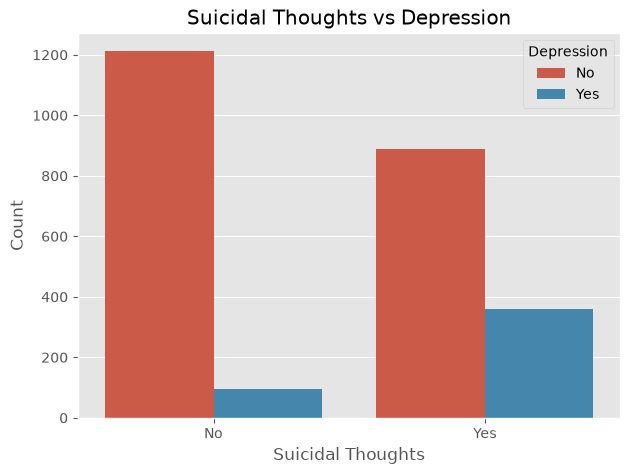

In [38]:
suicidal_labels = {
    0: "No",
    1: "Yes"
}

plt.figure(figsize=(7,5))

sns.countplot(
    x=df["Have you ever had suicidal thoughts ?"].map(suicidal_labels),
    hue=df["Depression"],
    order=["No", "Yes"]
)

plt.title("Suicidal Thoughts vs Depression")
plt.xlabel("Suicidal Thoughts")
plt.ylabel("Count")
plt.legend(title="Depression")

plt.show()

### Observation

- The number of participants without depression is higher than those with depression in both categories of suicidal thoughts.
- Participants who reported **having suicidal thoughts** show a substantially higher number of depression cases compared to those who did not report suicidal thoughts.
- Participants who **did not report suicidal thoughts** have a considerably lower number of depression cases.
- The visual difference between the two groups is much larger than that observed for many other features, indicating a strong association.
- Based on the visualization, suicidal thoughts appear to be strongly associated with depression. However, further statistical analysis is required to determine whether this relationship is statistically significant.

# 6. Correlation Analysis

Correlation analysis is performed to measure the strength and direction of the linear relationship between numerical features. It helps identify features that are strongly associated with the target variable and detects highly correlated variables that may influence model performance.

---

## 6.1 Correlation Heatmap

### Objective

To analyze the correlation among the selected features and identify their relationships with the target variable (Depression). The analysis also helps detect multicollinearity and understand which features are most strongly associated with depression.

### Code

In [42]:
selected_features = [
    "Age",
    "Gender",
    "Sleep Duration",
    "Dietary Habits",
    "Financial Stress",
    "Working Professional or Student",
    "Academic Pressure",
    "Work Pressure",
    "Study Satisfaction",
    "Job Satisfaction",
    "Family History of Mental Illness",
    "Have you ever had suicidal thoughts ?",
    "Depression"
]

corr_df = df[selected_features]

In [43]:
corr_matrix = corr_df.corr()

corr_matrix

,Age,Gender,Sleep Duration,Dietary Habits,Financial Stress,Working Professional or Student,Academic Pressure,Work Pressure,Study Satisfaction,Job Satisfaction,Family History of Mental Illness,Have you ever had suicidal thoughts ?,Depression
Age,1.000000,-0.004496,0.018632,0.007297,0.014578,0.516301,-0.479790,0.403905,-0.483656,0.378298,0.012606,0.007805,-0.485147
Gender,-0.004496,1.000000,0.021081,-0.036378,-0.012882,-0.010247,0.007691,-0.009692,0.009950,-0.003824,-0.019257,-0.011557,0.007595
Sleep Duration,0.018632,0.021081,1.000000,-0.014260,0.037989,-0.012993,0.013755,-0.023535,0.008968,-0.009471,-0.009693,-0.008964,-0.062574
Dietary Habits,0.007297,-0.036378,-0.014260,1.000000,-0.033078,0.000173,0.002083,0.001933,0.003311,0.014264,0.020479,-0.041419,-0.108215
Financial Stress,0.014578,-0.012882,0.037989,-0.033078,1.000000,0.014117,-0.012657,0.022016,-0.019174,0.007606,-0.027119,0.018301,0.165669
Working Professional or Student,0.516301,-0.010247,-0.012993,0.000173,0.014117,1.000000,-0.932637,0.782782,-0.936159,0.782028,0.014814,-0.028952,-0.418708
Academic Pressure,-0.479790,0.007691,0.013755,0.002083,-0.012657,-0.932637,1.000000,-0.730052,0.860212,-0.729348,-0.017921,0.032951,0.490045
Work Pressure,0.403905,-0.009692,-0.023535,0.001933,0.022016,0.782782,-0.730052,1.000000,-0.732808,0.607207,-0.014129,-0.035189,-0.241797
Study Satisfaction,-0.483656,0.009950,0.008968,0.003311,-0.019174,-0.936159,0.860212,-0.732808,1.000000,-0.732102,-0.007958,0.028605,0.332207
Job Satisfaction,0.378298,-0.003824,-0.009471,0.014264,0.007606,0.782028,-0.729348,0.607207,-0.732102,1.000000,0.004212,-0.036427,-0.400182


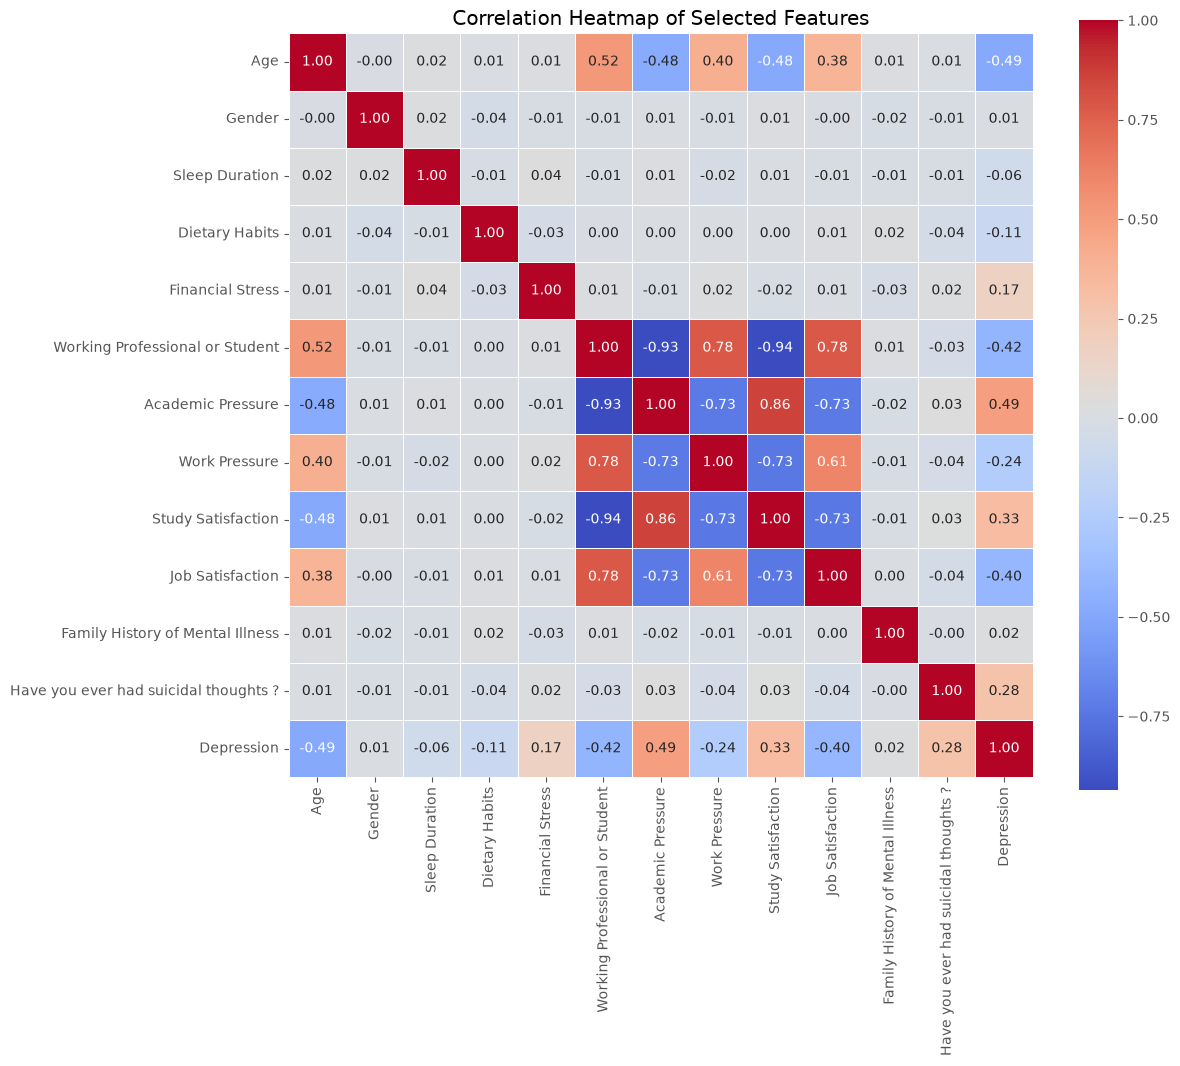

In [44]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Selected Features")

plt.show()

### Observation

- The correlation heatmap illustrates the strength and direction of the linear relationships among the selected features.
- **Academic Pressure** shows the strongest positive correlation with **Depression** (0.49), indicating that higher academic pressure is associated with a higher likelihood of depression.
- **Age** (-0.49) and **Job Satisfaction** (-0.40) exhibit moderate negative correlations with depression, suggesting that higher age and greater job satisfaction are associated with lower levels of depression.
- **Study Satisfaction** (0.33), **Suicidal Thoughts** (0.28), and **Financial Stress** (0.17) show positive correlations with depression, although the strength of these relationships varies.
- **Gender**, **Family History of Mental Illness**, **Sleep Duration**, and **Dietary Habits** have correlations close to zero, indicating weak linear relationships with depression in this dataset.
- Some independent features, such as **Academic Pressure**, **Study Satisfaction**, **Work Pressure**, and **Job Satisfaction**, exhibit strong correlations with one another. This is expected because these variables represent related aspects of participants' academic and professional experiences.
- Correlation analysis provides useful insights into linear relationships; however, correlation does not imply causation. Further analysis using machine learning models and feature importance techniques is required to determine the actual predictive contribution of each feature.